<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%201/2_opt_no_lineal_sin_restricciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1 - Punto 2

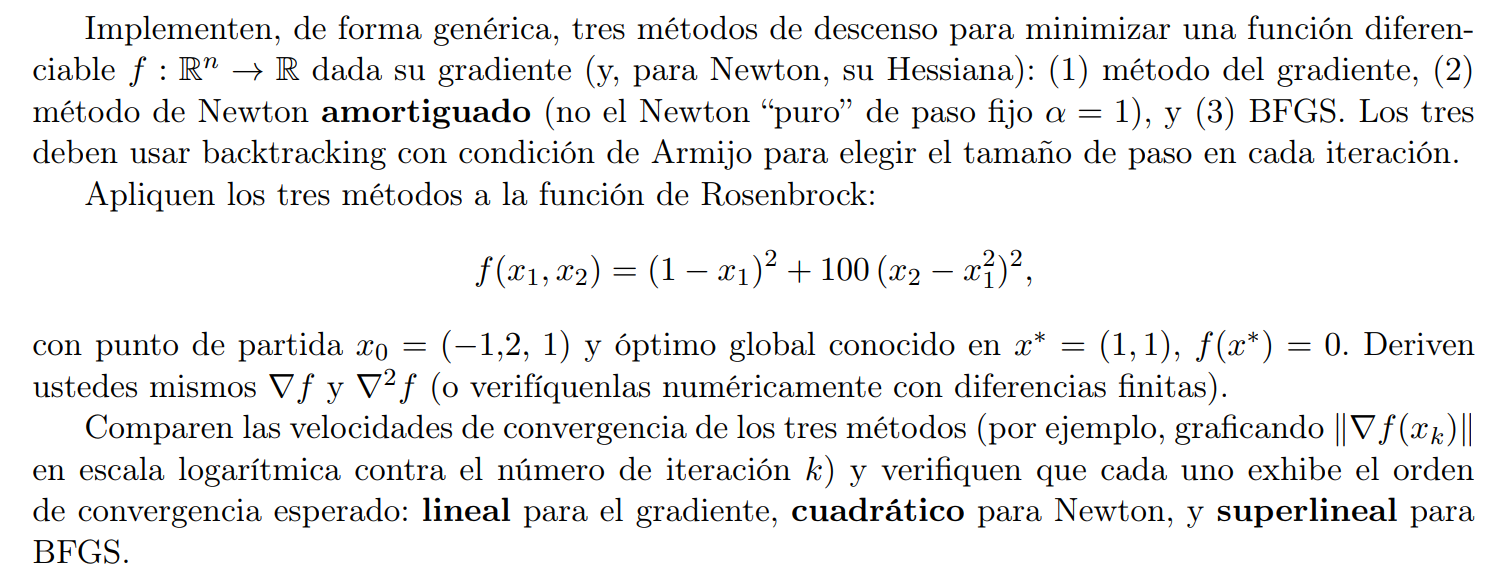

In [1]:
# Cargar librerías
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# Función de Rosenbrock

In [2]:
def rosenbrock(x1, x2):
  """
  Función de Rosenbrock (o banana) usada para testear algoritmos de optimización.
  """
  return (1 - x1)**2 + 100 * (x2 - x1**2)**2

In [3]:
# Crear malla para graficar un ejemplo
x1 = np.linspace(-2, 2, 100)
x2 = np.linspace(-1, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = rosenbrock(X1, X2)

# Visualizar la función de rosenbrock en 3D con plotly
fig = go.Figure(data=[go.Surface(
    z=Z, x=X1, y=X2,
    contours={
        "x": {"show": True, "start": -2, "end": 2, "size": 0.2, "color": "white"},
        "y": {"show": True, "start": -1, "end": 3, "size": 0.2, "color": "white"},
    }
)])

# Ajustes gráficos
fig.update_layout(
    width=700,
    height=700,
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='f(x₁, x₂)',
        aspectmode='cube'
    ),
    margin=dict(l=30, r=30, t=30, b=60)  # tamaño del marco alrededor de la figura
)

fig

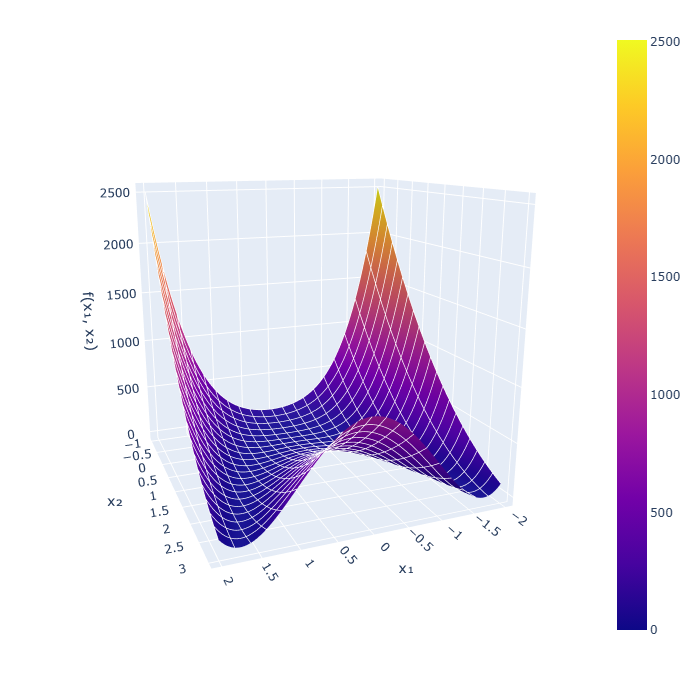

# Método del Gradiente Descendente

\begin{gather*}
f_k(d) = f(x_k) + \nabla f(x_k)^Td\\
x_{k+1} = x_k + \alpha_k d_k
\end{gather*}
Donde
- $d=x-x_k$.
- $x_k$ es el valor del punto $x$ en la iteración $k$.
- $\alpha_k$ es el tamaño de paso en la iteración $k$, encontrado por el método de búsqueda de línea inexacta con criterio de armijo ($\rho=1/2$, $c_1=1\mathrm{e}-4$).
- $d_k = - \nabla f(x)$ es la dirección dada por el gradiente. Básicamente nos dice en qué dirección ir, pero ignora cualquier información de curvatura de la función.

In [4]:
# Funciones auxiliares

# Función para aproximar el gradiente de f usando diferencias finitas centradas
def gradiente_numerico(f, x, h=1e-5):
  """
  Aproximación del gradiente de una función usando diferencias finitas centradas.
  """
  x = np.asarray(x, dtype=float) # array tipo float
  C = np.eye(len(x)) * h # Matriz I*h
  return np.array([(f(x + c) - f(x - c)) / (2 * h) for c in C])

# Función para hacer la búsqueda lineal inexacta por criterio de Armijo
def busqueda_lineal_armijo(f, grad_f, x, d, phi0, alpha=1, rho=0.5, c1=1e-4):
  """
  Función para realizar la búsqueda de línea inexacta usando la conndición de Armijo.
  Se pasa phi0 para evitar el costo de volver a evaluar.
  """
  phi_alpha = f(x + alpha * d)
  grad_phi_alpha = np.dot(grad_f, d)
  while phi_alpha > phi0 + c1 * alpha * grad_phi_alpha:
    alpha = rho * alpha
    phi_alpha = f(x + alpha * d)
  return alpha

In [5]:
def gradiente_descendente(f, x0, tol=1e-6, max_iter=1000, verbose=True, print_every=10):
  """
  Método del gradiente descendente para minimizar una función. Usa la búsqueda
  lineal inexacta con criterio de armijo para encontrar automáticamente el tamaño
  de paso alpha. Tiene criterio de parada por tolerancia con la norma y un número
  máximo de iteraciones como control de parada.
  """

  # Parámetros iniciales
  x = np.asarray(x0, dtype=float)
  historial_x = [x.copy()]
  historial_norma = [np.linalg.norm(gradiente_numerico(f, x))]  # norma en x0

  # Ciclo principal
  for i in range(max_iter):
    fx = f(x) # evaluar la función en el punto
    grad_f = gradiente_numerico(f, x) # Calcular el gradiente numéricamente
    norma_gradiente = np.linalg.norm(grad_f)

    if verbose and i % print_every == 0:
      print(f"Iter {i:4d} | f(x) = {fx:>10.4g} | ||grad|| = {norma_gradiente:>10.4g} | x = {x}")

    # Criterio de parada
    if norma_gradiente < tol:
      if verbose:
        print(f"\nConvergencia alcanzada en la iteración {i} | f(x) = {fx:.4g}")
      break # Parar si la norma del gradiente es menor que la tolerancia

    d = -grad_f # Dirección
    alpha = busqueda_lineal_armijo(f, grad_f, x, d, fx) # Tamaño de paso
    x = x + alpha * d # Próximo valor

    # Guardar valores en el historial
    historial_x.append(x.copy())
    historial_norma.append(norma_gradiente)

  return x, np.array(historial_x), np.array(historial_norma)

In [6]:
# Función y punto inicial
f = lambda x: rosenbrock(x[0], x[1])
x0 = np.array([-1, 1])

In [7]:
optimo_gradiente, historial_gradiente, norma_gradiente = gradiente_descendente(f, x0, max_iter=100, print_every=10)
print(optimo_gradiente)

Iter    0 | f(x) =          4 | ||grad|| =          4 | x = [-1.  1.]
Iter   10 | f(x) =  7.256e-14 | ||grad|| =  1.202e-05 | x = [0.99999999 1.00000001]
Iter   20 | f(x) =  2.976e-14 | ||grad|| =  7.684e-06 | x = [1.         1.00000001]
Iter   30 | f(x) =  1.224e-14 | ||grad|| =  4.913e-06 | x = [1.         1.00000001]
Iter   40 | f(x) =  5.048e-15 | ||grad|| =  3.141e-06 | x = [1.         1.00000001]
Iter   50 | f(x) =  2.095e-15 | ||grad|| =  2.008e-06 | x = [1.         1.00000001]

Convergencia alcanzada en la iteración 56 | f(x) = 8.976e-18
[1.         1.00000001]


# Método de Newton Amortiguado

\begin{gather*}
q_k(d) = f(x_k) + \nabla f(x_k)^T d + \frac{1}{2} d^T \nabla^2 f(x_k) d\\
x_{k+1} = x_k + \alpha_k d_k
\end{gather*}
Donde
- $d=x-x_k$.
- $x_k$ es el valor del punto $x$ en la iteración $k$.
- $\alpha_k$ es el tamaño de paso en la iteración $k$, encontrado por el método de búsqueda de línea inexacta con criterio de armijo ($\rho=1/2$, $c_1=1\mathrm{e}-4$).
- $d_k = - [\nabla^2 f(x)]^{-1}\nabla f(x)$ es la dirección dada por la matriz hessiana + el gradiente. Básicamente nos dice en qué dirección ir teniendo en cuenta la curvatura de la función (modelo cuadrático).

In [8]:
# Funciones auxiliares

def hessiana_numerica(f, x, h=1e-5):
  """
  Aproximación numérica de la matriz Hessiana de f en x, usando diferencias finitas
  centradas aplicadas al gradiente con la función creada previamente (gradiente_numerico).
  """
  grad_func = lambda x: gradiente_numerico(f, x, h)
  H = gradiente_numerico(grad_func, x, h)
  return (H + H.T) / 2  # Se simetriza para reducir el ruido por aproximación numérica

In [9]:
def newton_amortiguado(f, x0, tol=1e-6, max_iter=1000, verbose=True, print_every=10):
  """
  Método de Newton amortiguado (damped Newton) para minimizar una función.
  Usa la Hessiana numérica para calcular la dirección de Newton y la búsqueda
  lineal inexacta con criterio de Armijo para encontrar el tamaño de paso alpha.
  """

  # Parámetros iniciales
  x = np.asarray(x0, dtype=float)
  historial_x = [x.copy()]
  historial_norma = [np.linalg.norm(gradiente_numerico(f, x))]

  # Ciclo principal
  for i in range(max_iter):
    fx = f(x)
    grad_f = gradiente_numerico(f, x)
    norma_gradiente = np.linalg.norm(grad_f)

    if verbose and i % print_every == 0:
      print(f"Iter {i:4d} | f(x) = {fx:>10.4g} | ||grad|| = {norma_gradiente:>10.4g} | x = {x}")

    # Criterio de parada
    if norma_gradiente < tol:
      if verbose:
        print(f"\nConvergencia alcanzada en la iteración {i} | f(x) = {fx:.4g}")
      break

    H = hessiana_numerica(f, x) # Hessiana numérica
    d = np.linalg.solve(H, -grad_f) # Dirección de Newton

    alpha = busqueda_lineal_armijo(f, grad_f, x, d, fx) # Tamaño de paso
    x = x + alpha * d # Próximo valor

    # Guardar valores en el historial
    historial_x.append(x.copy())
    historial_norma.append(norma_gradiente)

  return x, np.array(historial_x), np.array(historial_norma)

In [10]:
optimo_newton, historial_newton, norma_newton = newton_amortiguado(f, x0, max_iter=100, print_every=10)
print(optimo_newton)

Iter    0 | f(x) =          4 | ||grad|| =          4 | x = [-1.  1.]
Iter   10 | f(x) =     0.2119 | ||grad|| =      2.296 | x = [0.54995542 0.29276082]
Iter   20 | f(x) =      4e-16 | ||grad|| =  5.104e-12 | x = [0.99999998 0.99999996]

Convergencia alcanzada en la iteración 20 | f(x) = 4e-16
[0.99999998 0.99999996]


# BFGS (Quasi-Newton)

\begin{gather*}
q_k(d) = f(x_k) + \nabla f(x_k)^T d + \frac{1}{2} d^T \nabla^2 f(x_k) d\\
x_{k+1} = x_k + \alpha_k d_k
\end{gather*}
Donde
- $d=x-x_k$.
- $x_k$ es el valor del punto $x$ en la iteración $k$.
- $\alpha_k$ es el tamaño de paso en la iteración $k$, encontrado por el método de búsqueda de línea inexacta con criterio de armijo ($\rho=1/2$, $c_1=1\mathrm{e}-4$).
- $d_k = - H_k \nabla f(x)$, es la dirección dada por $H_k$, la aproximación lineal de la matriz hessiana $[\nabla^2 f(x)]^{-1}$, y el gradiente.

Inicialmente, la mejor aproximación es $H_0 = I \Rightarrow d_k = -\nabla f(x)$, es decir, la dirección del gradiente pues no se tiene información de la curvatura. Por otro lado, se definen las variables
\begin{gather*}
s_k = x_{k+1}-x_k, \quad y_k = \nabla f(x_{k+1}) - \nabla f(x_k)
\end{gather*}
tal que se debe cumplir la ecuación secante $H_{k+1}y_k = s_k$. Como existen infinitas $H_k$ que satisfacen la ecuación, los autores definen
\begin{gather*}
\rho_k = \frac{1}{y_k^T s_k}, \quad H_{k+1} = (I-\rho_k s_k y_k^T)H_k(I-\rho_k y_k s_k^T) + \rho_k s_k s_k^T
\end{gather*}

In [11]:
def bfgs(f, x0, tol=1e-6, max_iter=1000, verbose=True, print_every=10):
  """
  Método BFGS (Quasi-Newton) para minimizar una función. Aproxima iterativamente
  la inversa de la Hessiana (H_k) usando únicamente evaluaciones del gradiente,
  sin calcular la Hessiana real. Usa la búsqueda lineal inexacta con criterio
  de Armijo para encontrar el tamaño de paso alpha.
  """

  # Parámetros iniciales
  x = np.asarray(x0, dtype=float)
  n = len(x)
  H = np.eye(n) # H_0 = I pues no hay información de curvatura todavía, primer paso = gradiente descendente
  grad_f = gradiente_numerico(f, x)

  historial_x = [x.copy()]
  historial_norma = [np.linalg.norm(grad_f)]

  # Ciclo principal
  for i in range(max_iter):
    fx = f(x)
    norma_gradiente = np.linalg.norm(grad_f)

    if verbose and i % print_every == 0:
      print(f"Iter {i:4d} | f(x) = {fx:>10.4g} | ||grad|| = {norma_gradiente:>10.4g} | x = {x}")

    # Criterio de parada
    if norma_gradiente < tol:
      if verbose:
        print(f"\nConvergencia alcanzada en la iteración {i} | f(x) = {fx:.4g}")
      break

    d = -H @ grad_f # Dirección Quasi-Newton

    alpha = busqueda_lineal_armijo(f, grad_f, x, d, fx) # Tamaño de paso
    x_nuevo = x + alpha * d # Próximo valor
    grad_f_nuevo = gradiente_numerico(f, x_nuevo)

    # Actualización BFGS de H
    s = (x_nuevo - x).reshape(-1, 1)
    y = (grad_f_nuevo - grad_f).reshape(-1, 1)
    rho = 1.0 / (y.T @ s).item()

    I = np.eye(n)
    H = (I - rho * s @ y.T) @ H @ (I - rho * y @ s.T) + rho * s @ s.T

    # Avanzar a la siguiente iteración
    x = x_nuevo
    grad_f = grad_f_nuevo

    # Guardar valores en el historial
    historial_x.append(x.copy())
    historial_norma.append(norma_gradiente)

  return x, np.array(historial_x), np.array(historial_norma)

In [12]:
optimo_bfgs, historial_bfgs, norma_bfgs = bfgs(f, x0, max_iter=100, print_every=10)
print(optimo_newton)

Iter    0 | f(x) =          4 | ||grad|| =          4 | x = [-1.  1.]

Convergencia alcanzada en la iteración 3 | f(x) = 5.381e-18
[0.99999998 0.99999996]


# Comparación: trayectorias y velocidad de convergencia

In [13]:
def graficar_curvas_nivel(f, x1_range=(-2, 2), x2_range=(-1, 3), n=200,
                            trayectorias=None, niveles=30, log_scale=False,
                            titulo=None):
  """
  Grafica las curvas de nivel de una función f(x1, x2) y opcionalmente las trayectorias
  de convergencia de algoritmos de optimización
  """

  # Crear malla
  x1 = np.linspace(*x1_range, n)
  x2 = np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  Z = f(X1, X2)

  # Parámetros de la figura y ejes
  fig, ax = plt.subplots(figsize=(8, 6))

  if log_scale:
    z_min = max(Z.min(), 1e-10)
    levels = np.logspace(np.log10(z_min), np.log10(Z.max()), niveles)
  else:
    levels = niveles

  cf = ax.contourf(X1, X2, Z, levels=levels, cmap='viridis', alpha=0.3)
  ax.contour(X1, X2, Z, levels=levels, cmap='viridis')
  fig.colorbar(cf, ax=ax, label='f(x1, x2)')

  # Superponer trayectorias si se pasan
  if trayectorias:
    colores = plt.cm.tab10.colors
    for idx, (nombre, historial) in enumerate(trayectorias.items()):
      historial = np.asarray(historial)
      color = colores[idx % len(colores)]
      ax.plot(historial[:, 0], historial[:, 1], 'o-', color=color,
              markersize=3, linewidth=1.2, label=nombre)
      ax.plot(*historial[0], 'o', color=color, markersize=8, markeredgecolor='black')   # inicio
      ax.plot(*historial[-1], '*', color=color, markersize=14, markeredgecolor='black') # final
    ax.legend()

  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.set_title(titulo or 'Curvas de nivel')
  plt.tight_layout()
  plt.show()

In [14]:
def graficar_superficie_3d(f, x1_range=(-2, 2), x2_range=(-1, 3), n=100,
                             trayectorias=None, titulo=None):
  """
  Grafica la superficie 3D de f(x1, x2) con Plotly y opcionalmente superpone
  las trayectorias de convergencia de algoritmos de optimización.
  """

  # Crear malla
  x1 = np.linspace(*x1_range, n)
  x2 = np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  Z = f(X1, X2)

  data = [go.Surface(
      z=Z, x=X1, y=X2,
      contours={
          "x": {"show": True, "start": x1_range[0], "end": x1_range[1], "size": 0.2, "color": "white"},
          "y": {"show": True, "start": x2_range[0], "end": x2_range[1], "size": 0.2, "color": "white"},
      },
      opacity=0.85,
      colorscale='Viridis',
      showscale=True
  )]

  # Superponer trayectorias si se pasan
  if trayectorias:
    colores_plotly = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for idx, (nombre, historial) in enumerate(trayectorias.items()):
      historial = np.asarray(historial)
      color = colores_plotly[idx % len(colores_plotly)]
      z_historial = f(historial[:, 0], historial[:, 1]) + 5  # pequeño offset para que se vea sobre la superficie

      data.append(go.Scatter3d(
          x=historial[:, 0], y=historial[:, 1], z=z_historial,
          mode='lines+markers',
          line=dict(color=color, width=4),
          marker=dict(size=3, color=color),
          name=nombre
      ))
      # Punto inicial y final destacados
      data.append(go.Scatter3d(
          x=[historial[0, 0]], y=[historial[0, 1]], z=[z_historial[0]],
          mode='markers', marker=dict(size=6, color=color, symbol='circle',
                                        line=dict(color='black', width=1)),
          showlegend=False
      ))
      data.append(go.Scatter3d(
          x=[historial[-1, 0]], y=[historial[-1, 1]], z=[z_historial[-1]],
          mode='markers', marker=dict(size=8, color=color, symbol='diamond',
                                        line=dict(color='black', width=1)),
          showlegend=False
      ))

  fig = go.Figure(data=data)

  fig.update_layout(
      width=800,
      height=700,
      title=titulo,
      scene=dict(
          xaxis_title='x₁',
          yaxis_title='x₂',
          zaxis_title='f(x₁, x₂)',
          aspectmode='cube'
      ),
      legend=dict(
      x=0.02, y=0.98,           # esquina superior izquierda
      xanchor='left', yanchor='top',
      bgcolor='rgba(255,255,255,0.7)',  # fondo semitransparente para legibilidad
      bordercolor='black',
      borderwidth=1
      ),
      margin=dict(l=30, r=30, t=50, b=60)
  )

  return fig

In [15]:
def graficar_convergencia(velocidades, titulo='Convergencia'):
  """
  Grafica ||grad(f)|| vs iteración en escala semilogarítmica, para uno o más métodos.
  historiales_norma: dict, ej. {'gradiente': norma_gradiente}
  """
  fig, ax = plt.subplots(figsize=(8, 5))

  for nombre, velocidad in velocidades.items():
    ax.semilogy(velocidad, marker='o', markersize=3, linewidth=1.2, label=nombre)

  ax.set_xlabel(r'Iteración ($k$)')
  ax.set_ylabel(r'$||\nabla f(x)||$')
  ax.set_title(titulo)
  ax.grid(True, which='both', alpha=0.3)
  ax.legend()
  plt.tight_layout()
  plt.show()

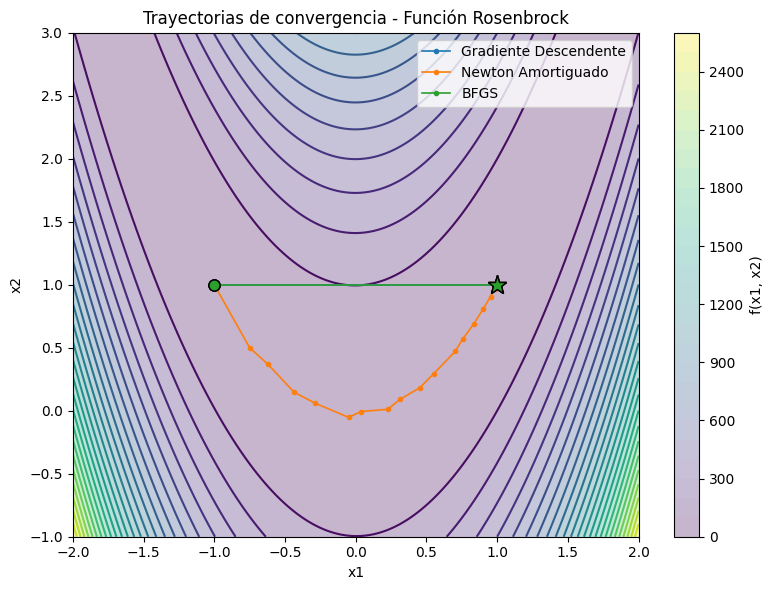

In [16]:
trayectorias_convergencia = {
    'Gradiente Descendente': historial_gradiente,
    'Newton Amortiguado': historial_newton,
    'BFGS': historial_bfgs
  }
graficar_curvas_nivel(lambda x1, x2: rosenbrock(x1,x2), trayectorias=trayectorias_convergencia, titulo='Trayectorias de convergencia - Función Rosenbrock')

In [17]:
graficar_superficie_3d(lambda x1, x2: rosenbrock(x1,x2), trayectorias=trayectorias_convergencia, titulo='Trayectorias de convergencia - Función Rosenbrock')

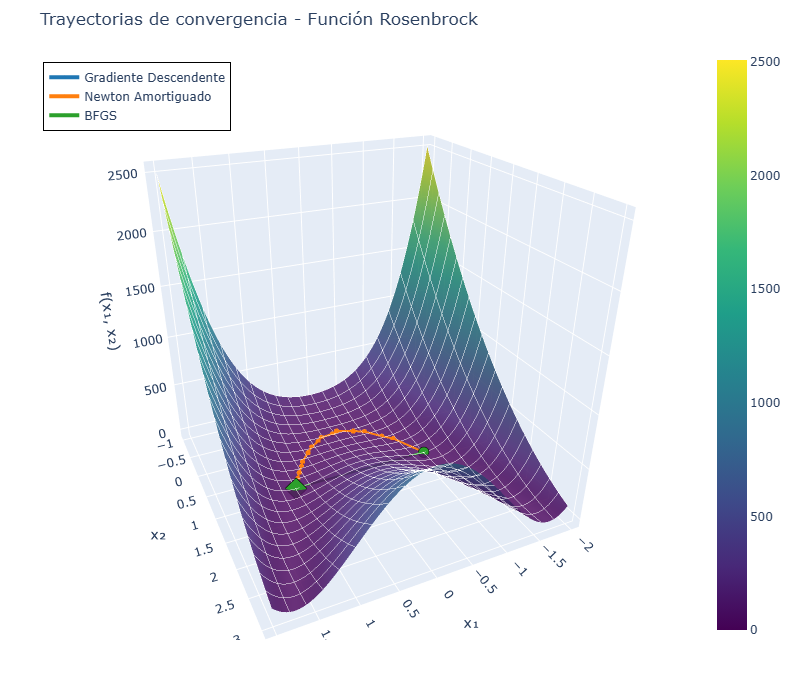

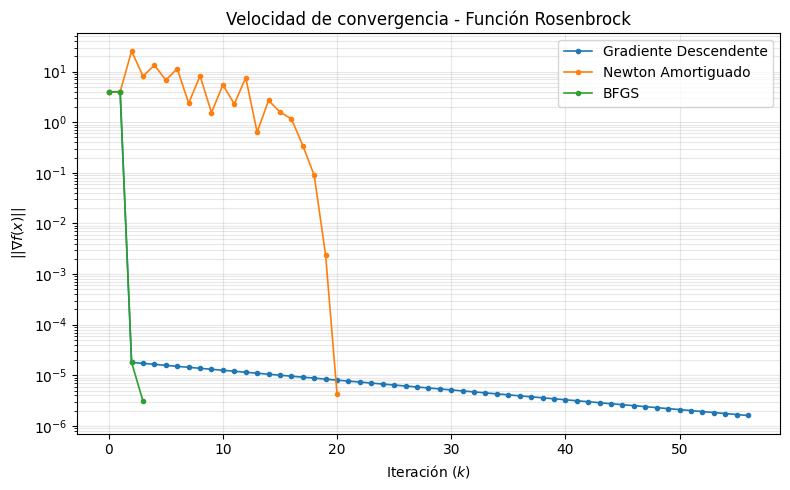

In [18]:
velocidades_convergencia = {
    'Gradiente Descendente': norma_gradiente,
    'Newton Amortiguado': norma_newton,
    'BFGS': norma_bfgs
}
graficar_convergencia(velocidades_convergencia, titulo='Velocidad de convergencia - Función Rosenbrock')

# Análisis

Partiendo del punto inicial $x_0 = (-1, 1)$, se observa el siguiente comportamiento en la velocidad de convergencia de cada algoritmo al óptimo $x^* = (1, 1)$ con una tolerancia de $1\rm{e}-6$:

- En primer lugar estuvo el método BFGS, el cual alcanzó el óptimo en $k=3$ iteraciones con un error de $||\nabla f(x^*)|| \approx 3.10 \rm{e} -6$.
- En segundo lugar estuvo el método de Newton Amortiguado, el cual alcanzó el óptimo en $k=20$ iteraciones con un error de $||\nabla f(x^*)|| \approx 4.21 \rm{e} -6$.
- En último lugar estuvo el método de Gradiente Descendente, el cual alcanzó el óptimo en $k=56$ iteraciones con un error de $||\nabla f(x^*)|| \approx 1.61 \rm{e} -6$.
- Se observa que las velocidades de convergencia tuvieron un comportamiento lineal, superlineal y cuadrático para los métodos Gradiente, BFGS y Newton, respectivamente; lo cual es consistente con el orden de convergencia teórico de cada método.